# 23CSE301 Machine Learning – Capstone Project

**Team No:** 8

**Project Title:** Healthcare Cost Prediction and Patient Risk Intelligence Platform

**Target Variable:** `is_high_risk` (Classification Part A)

### Project Introduction
We train and evaluate all 5 required classification models individually on stratified train/test data.

In [1]:
import sys
sys.path.append('..')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib

import app.config as config
import app.preprocessing as preprocessing
import app.utils as utils

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve, auc

class DenseTransformer(TransformerMixin, BaseEstimator):
    def fit(self, X, y=None):
        return self
    def transform(self, X, y=None):
        if hasattr(X, 'toarray'):
            return X.toarray()
        return X

sns.set_theme(style='whitegrid')
np.random.seed(config.RANDOM_STATE)
print('Classification libraries loaded successfully.')

Classification libraries loaded successfully.


## Data Preprocessing and Stratified Split
Target variable `is_high_risk`. `risk_score` is dropped to prevent target leakage.

In [2]:
X_train, X_test, y_train, y_test, cat_cols, num_cols, bin_cols = preprocessing.prepare_data_classification()
preprocessor = preprocessing.get_preprocessor(cat_cols, num_cols, bin_cols)
print('Train Set Shape:', X_train.shape)
print('Test Set Shape:', X_test.shape)

cls_results = []
subsample_idx = np.random.choice(len(X_train), size=min(8000, len(X_train)), replace=False)
X_train_sub = X_train.iloc[subsample_idx]
y_train_sub = y_train.iloc[subsample_idx]

Train Set Shape: (80000, 57)
Test Set Shape: (20000, 57)


### 1. Logistic Regression

In [3]:
c_lr = Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
c_lr.fit(X_train, y_train)
p_lr = c_lr.predict(X_test)
prob_lr = c_lr.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': accuracy_score(y_test, p_lr),
    'Precision': precision_score(y_test, p_lr, zero_division=0),
    'Recall': recall_score(y_test, p_lr, zero_division=0),
    'Weighted F1': f1_score(y_test, p_lr, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_lr)
})
print('Logistic Regression complete.')

Logistic Regression complete.


### 2. K-Nearest Neighbors Classifier

In [4]:
c_knn = Pipeline([('prep', preprocessor), ('clf', KNeighborsClassifier(n_neighbors=7, n_jobs=-1))])
c_knn.fit(X_train_sub, y_train_sub)
p_knn = c_knn.predict(X_test)
prob_knn = c_knn.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'K-Nearest Neighbors',
    'Accuracy': accuracy_score(y_test, p_knn),
    'Precision': precision_score(y_test, p_knn, zero_division=0),
    'Recall': recall_score(y_test, p_knn, zero_division=0),
    'Weighted F1': f1_score(y_test, p_knn, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_knn)
})
print('KNN Classifier complete.')

KNN Classifier complete.


### 3. Gaussian Naive Bayes

In [5]:
c_gnb = Pipeline([('prep', preprocessor), ('to_dense', DenseTransformer()), ('clf', GaussianNB())])
c_gnb.fit(X_train, y_train)
p_gnb = c_gnb.predict(X_test)
prob_gnb = c_gnb.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Gaussian Naive Bayes',
    'Accuracy': accuracy_score(y_test, p_gnb),
    'Precision': precision_score(y_test, p_gnb, zero_division=0),
    'Recall': recall_score(y_test, p_gnb, zero_division=0),
    'Weighted F1': f1_score(y_test, p_gnb, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_gnb)
})
print('Gaussian Naive Bayes complete.')

Gaussian Naive Bayes complete.


### 4. Decision Tree Classifier

In [6]:
c_dt = Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(max_depth=8, random_state=42))])
c_dt.fit(X_train, y_train)
p_dt = c_dt.predict(X_test)
prob_dt = c_dt.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Decision Tree',
    'Accuracy': accuracy_score(y_test, p_dt),
    'Precision': precision_score(y_test, p_dt, zero_division=0),
    'Recall': recall_score(y_test, p_dt, zero_division=0),
    'Weighted F1': f1_score(y_test, p_dt, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_dt)
})
print('Decision Tree Classifier complete.')

Decision Tree Classifier complete.


### 5. Support Vector Classifier

In [7]:
c_svc = Pipeline([('prep', preprocessor), ('clf', CalibratedClassifierCV(SVC(C=1.0, random_state=42), ensemble=False))])
c_svc.fit(X_train_sub, y_train_sub)
p_svc = c_svc.predict(X_test)
prob_svc = c_svc.predict_proba(X_test)[:, 1]
cls_results.append({
    'Model': 'Support Vector Machine',
    'Accuracy': accuracy_score(y_test, p_svc),
    'Precision': precision_score(y_test, p_svc, zero_division=0),
    'Recall': recall_score(y_test, p_svc, zero_division=0),
    'Weighted F1': f1_score(y_test, p_svc, average='weighted'),
    'ROC-AUC': roc_auc_score(y_test, prob_svc)
})
print('Support Vector Classifier complete.')

Support Vector Classifier complete.


## Classification Model Comparison
Consolidated metrics for all 5 classification algorithms:

In [8]:
df_cls = pd.DataFrame(cls_results).sort_values(by='Weighted F1', ascending=False).reset_index(drop=True)
df_cls.index += 1
df_cls

,Model,Accuracy,Precision,Recall,Weighted F1,ROC-AUC
1,Decision Tree,0.99795,0.997822,0.996601,0.997950,0.999579
2,Logistic Regression,0.99680,0.996866,0.994426,0.996799,0.999755
3,Support Vector Machine,0.96600,0.958769,0.948341,0.965961,0.996215
4,K-Nearest Neighbors,0.85860,0.913290,0.680125,0.853142,0.939874
5,Gaussian Naive Bayes,0.83615,0.784727,0.764138,0.835681,0.911299


## Confusion Matrices and ROC Curve

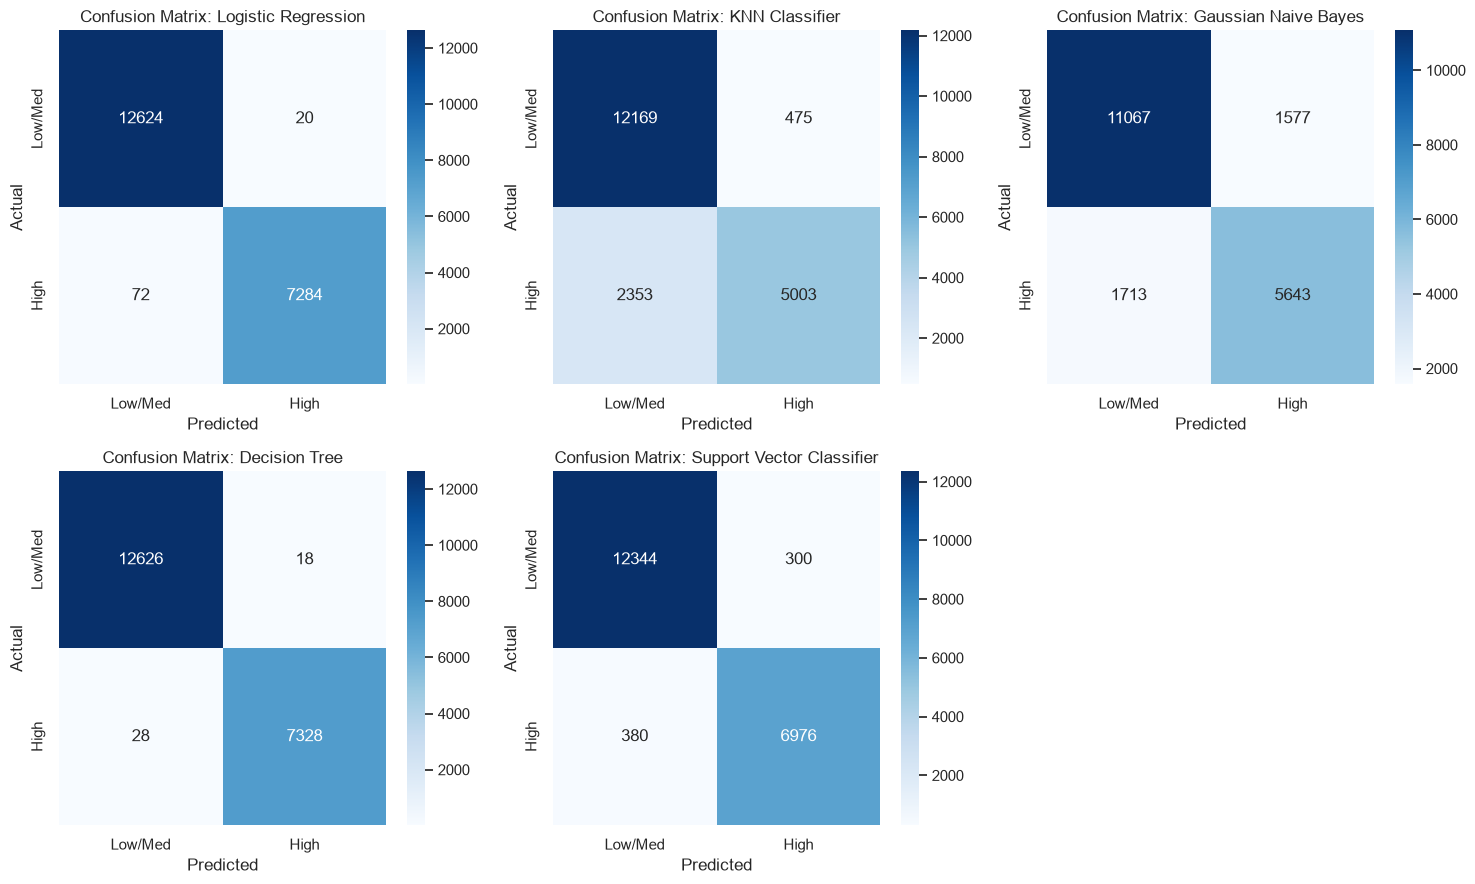

In [9]:
all_models = {'Logistic Regression': c_lr, 'KNN Classifier': c_knn, 'Gaussian Naive Bayes': c_gnb, 'Decision Tree': c_dt, 'Support Vector Classifier': c_svc}
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for idx, (name, model) in enumerate(all_models.items()):
    preds = model.predict(X_test)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], xticklabels=['Low/Med', 'High'], yticklabels=['Low/Med', 'High'])
    axes[idx].set_title(f'Confusion Matrix: {name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')
axes[5].axis('off')
plt.tight_layout()
plt.show()

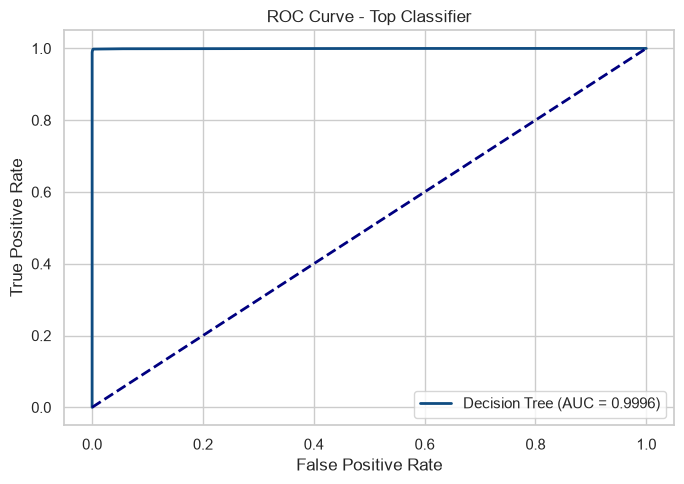

In [10]:
fpr, tpr, _ = roc_curve(y_test, prob_dt)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='#0F4C81', lw=2, label=f'Decision Tree (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title('ROC Curve - Top Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()